In [135]:
import os
from sklearn.pipeline import Pipeline
from model_class.feature_builder import FeatureBuilder
from model_class.feature_builder_transformer import FeatureBuilderTransformer
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve


1.Import data

In [136]:
# Get the current directory
current_directory = os.getcwd()

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_training_data.csv"
df_train = pd.read_csv(file, header=0)

y_train = df_train['evil']
X_train = df_train.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_testing_data.csv"
df_test = pd.read_csv(file, header=0)
y_test = df_test['evil']
X_test = df_test.drop(columns=['sus', 'evil'])

2. build features

In [137]:
# build_features = FeatureBuilder()

# FeatureBuilder.fit(build_features, X_train)
# df_train = FeatureBuilder.transform(build_features, X_train)
# df_test = FeatureBuilder.transform(build_features, X_test)

# print(df_train.info())
# print(df_test.info()) 

# df_train.to_csv(f"{current_directory}/datasets/processed/feature_engineered_training_data.csv", index=False)
# df_test.to_csv(f"{current_directory}/datasets/processed/feature_engineered_testing_data.csv", index=False)

In [138]:
n = len(X_test)
cont = max(1/n, 0.001)

In [146]:
scale_cols = [
    "processId_freq",
    "threadId_freq",
    "parentProcessId_freq",
    "userId_freq",
    "mountNamespace_freq",
    "eventId_freq",
    "stackAddresses_len",
    "returnValue",
    "argsNum",
    "stackAddresses_jump_std"
]

passthrough_cols = [
    "hostName_hash",
    "processName_hash",
    "parentProcessName_hash",
    "is_system_process",
    "is_parent_system_process",
    "userId_binary",
    "parentUserId_binary",
    "same_user_as_parent",
    "same_process_name_as_parent",
    "stackAddresses_unique_ratio",
    "returnValue_is_error",
    "args_has_path",
    "mountNamespace_binary"
]



scaler = ColumnTransformer(
    transformers=[
        ("scale", RobustScaler(), scale_cols),
        ("pass", "passthrough", passthrough_cols),
    ]
)

model = Pipeline([
    ("features", FeatureBuilderTransformer(FeatureBuilder(), return_numpy=False)),
    ("scaler", scaler),
    ("iforest", IsolationForest(
            n_estimators=300,
            contamination="auto",
            max_features=0.7,
            random_state=2000
        ))

])


In [147]:
y_pred_train = model.fit(X_train)

In [148]:
# Perform fit on X _train and returns labels for y_pred.
y_pred_train = model.fit_predict(X_train)

In [149]:
# Perform fit on X _train and returns labels for y_pred.
y_pred_test = model.predict(X_test)

1. Isolation Forest

In [150]:

def evaluate_model(y_true, y_pred, dataset_type="Dataset"):
    # Returns -1 for outliers and 1 for inliers.
    # change -1 to 0:
    y_pred = np.where(y_pred == -1, 1, 0)

    # Get unique values and their counts in y_true
    unique_values, counts = np.unique(y_true, return_counts=True)
    print(f"y_true Unique values: {unique_values}")
    print(f"y_true Counts of each value: {counts}")

    # Get unique values and their counts in y_pred
    unique_values, counts = np.unique(y_pred, return_counts=True)
    print(f"y_pred Unique values: {unique_values}")
    print(f"y_pred Counts of each value: {counts}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Inlier", "Outlier"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {dataset_type}')
    plt.show()

    # ROC AUC Score
    roc_auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)

    print(f"False Positive Rate: {fpr}")
    print(f"True Positive Rate: {tpr}")
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic for {dataset_type}')
    plt.legend(loc="lower right")
    plt.show()
# # Returns -1 for outliers and 1 for inliers.
# # change -1 to 0:
# y_pred = np.where(y_pred == -1, 1, 0)

# # Get unique values and their counts in y_pred
# unique_values, counts = np.unique(y_pred, return_counts=True)
# print(f"Unique values: {unique_values}")
# print(f"Counts of each value: {counts}")

# # Get unique values and their counts in y_train
# unique_values, counts = np.unique(y_train, return_counts=True)
# print(f"Unique values: {unique_values}")
# print(f"Counts of each value: {counts}")

y_true Unique values: [0]
y_true Counts of each value: [763144]
y_pred Unique values: [0 1]
y_pred Counts of each value: [636828 126316]
[[636828 126316]
 [     0      0]]


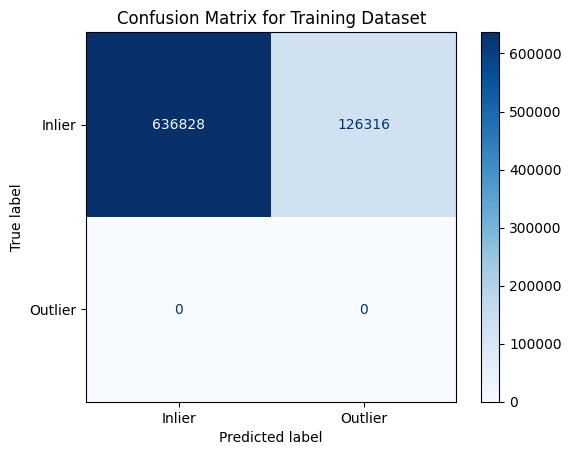

False Positive Rate: [0.         0.16552053 1.        ]
True Positive Rate: [nan nan nan]


/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


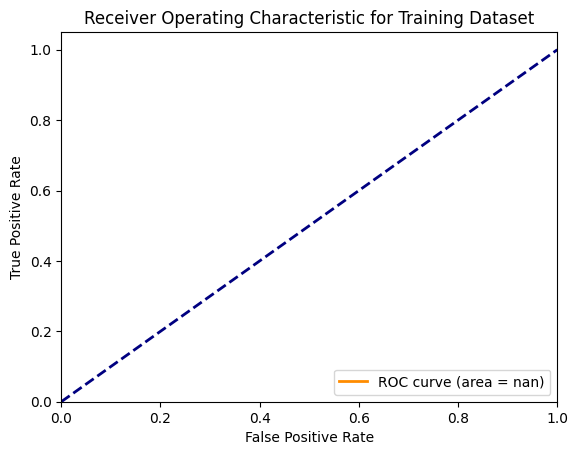

y_true Unique values: [0 1]
y_true Counts of each value: [ 30535 158432]
y_pred Unique values: [0 1]
y_pred Counts of each value: [  9187 179780]
[[  8507  22028]
 [   680 157752]]


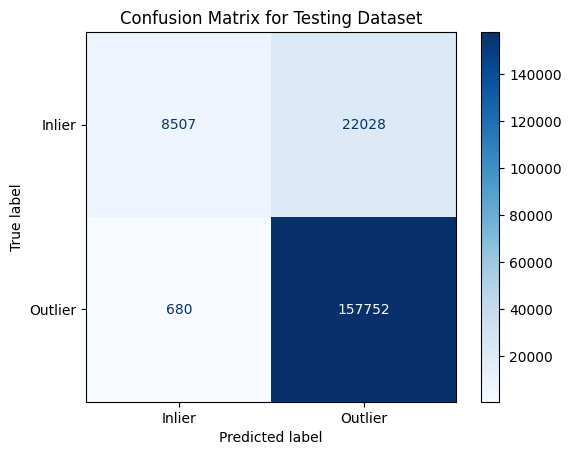

False Positive Rate: [0.         0.72140167 1.        ]
True Positive Rate: [0.         0.99570794 1.        ]


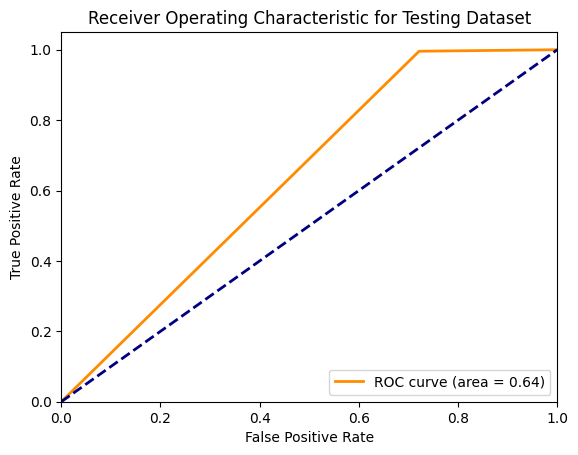

In [151]:
evaluate_model(y_train, y_pred_train, dataset_type="Training Dataset")
evaluate_model(y_test, y_pred_test, dataset_type="Testing Dataset")

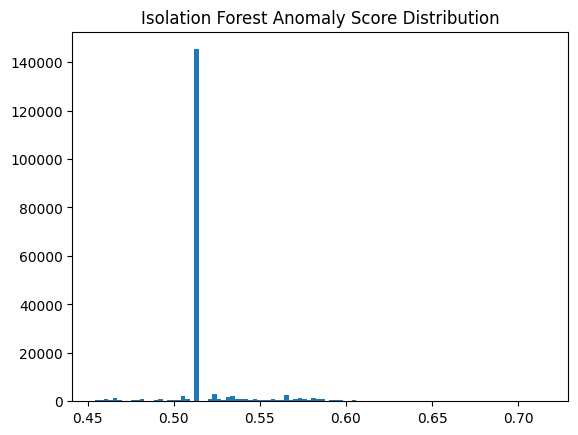

In [152]:
anomaly_scores = pipe.score_samples(X_test)

anomaly_scores = -anomaly_scores  # Invert scores so that higher values indicate more anomalous instances
plt.hist(anomaly_scores, bins=100)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.show()